<a href="https://colab.research.google.com/github/ashishranjaniitbcmi/Project3-fii-dii/blob/main/fii_dii.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
project_root = "/content/drive/MyDrive/Project2"
folders = ['raw_data', 'processed_data', 'plots', 'notebooks']


for folder in folders:
    path = os.path.join(project_root, folder)
    os.makedirs(path, exist_ok=True)
    print(f"Created: {path}")

Created: /content/drive/MyDrive/Project2/raw_data
Created: /content/drive/MyDrive/Project2/processed_data
Created: /content/drive/MyDrive/Project2/plots
Created: /content/drive/MyDrive/Project2/notebooks


In [ ]:
!pip install yfinance --quiet
!pip install openpyxl --quiet
!pip install pandas_ta --quiet

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

sns.set(style="whitegrid")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.1/115.1 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


Here, I started by loading the daily data of FII and DII from 2014 to 2023.
It includes gross purchases, gross sales, and net values for both FII and DII.

After loading the data, I cleaned it by converting the date column properly, fixing missing values, and selecting only the useful columns.
This data will later be used to study its effect on the Nifty 50 index.

In [ ]:

file_path = "/content/drive/MyDrive/Project2/raw_data/fii_dii.xlsx"
df = pd.read_excel(file_path)

# Clean column names
df.columns = [col.strip().lower().replace(' ', '_').replace('/', '_') for col in df.columns]

# Parse date and clean numbers
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

for col in df.columns:
    if col != 'date':
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

# Save CSV
df = df.sort_values('date')
csv_path = "/content/drive/MyDrive/Project2/raw_data/fii_dii_data.csv"
df.to_csv(csv_path, index=False)

print(f"Cleaned and saved {len(df)} rows to: {csv_path}")
df.head()


Cleaned and saved 2968 rows to: /content/drive/MyDrive/Project2/raw_data/fii_dii_data.csv


/tmp/ipython-input-17-2775926292.py:8: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'], dayfirst=True)


,date,fii_gross_purchase,fii_gross_sales,fii_net_purchase_sales,dii_net_purchase_sales,dii_gross_sales,dii_gross_purchase
2967,2014-01-01,225.1,215.0,10.2,-222.1,581.3,359.2
2966,2014-01-02,2396.2,1722.1,674.0,-189.8,1104.4,914.7
2965,2014-01-03,1877.0,1895.0,-18.1,-280.8,1208.0,927.3
2964,2014-01-06,1928.9,2247.8,-318.9,-22.5,1103.4,1080.8
2963,2014-01-07,2227.9,2794.9,-567.0,59.4,1056.2,1115.7


In this step, I downloaded Nifty 50 daily data for the last 2 years using Yahoo Finance.

Then, I calculated the return for the next 1 day and 5 days based on the closing price.
These returns are what I want to predict using the FII and DII activity.

Finally, I saved the Nifty data so I can merge it later with the institutional data.


In [ ]:
# Download 2 years of Nifty data
nifty = yf.download("^NSEI", start="2022-07-01", end=datetime.today().strftime("%Y-%m-%d"))

# Reset index for easy merge later
nifty.reset_index(inplace=True)

# Calculate 1-day and 5-day forward returns
nifty['nifty_return_1d'] = nifty['Close'].pct_change().shift(-1) * 100
nifty['nifty_return_5d'] = nifty['Close'].pct_change(periods=5).shift(-5) * 100

# Save
nifty.to_csv(f"{project_root}/raw_data/nifty_data.csv", index=False)
print("Nifty data saved.")
nifty.tail()


/tmp/ipython-input-7-3738133585.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty = yf.download("^NSEI", start="2022-07-01", end=datetime.today().strftime("%Y-%m-%d"))
[*********************100%***********************]  1 of 1 completed

Nifty data saved.


Price,Date,Close,High,Low,Open,Volume,nifty_return_1d,nifty_return_5d
Ticker,,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI,,
737,2025-06-30,25517.050781,25669.349609,25473.300781,25661.650391,271000,0.096994,NaN
738,2025-07-01,25541.800781,25593.400391,25501.800781,25551.349609,260700,-0.346101,NaN
739,2025-07-02,25453.400391,25608.099609,25378.750000,25588.300781,309800,-0.188971,NaN
740,2025-07-03,25405.300781,25587.500000,25384.349609,25505.099609,293400,0.219243,NaN
741,2025-07-04,25461.000000,25470.250000,25331.650391,25428.849609,193500,NaN,NaN


Now, I merged the FII/DII data with the Nifty return data using the date column.

To improve prediction, I also created a few new features like:

FII/DII net value from the previous day

5-day average of FII/DII net activity

These features may help the model capture recent trends.
After this, I removed rows with missing values and saved the clean data for modeling.



In [ ]:
import pandas as pd

fii_dii_path = "/content/drive/MyDrive/Project2/raw_data/fii_dii_data.csv"
nifty_path = "/content/drive/MyDrive/Project2/raw_data/nifty_data.csv"

fii_dii = pd.read_csv(fii_dii_path, parse_dates=['date'])
nifty = pd.read_csv(nifty_path, parse_dates=['Date'])
nifty.rename(columns={'Date': 'date'}, inplace=True)

# Merge on 'date'
merged = pd.merge(nifty, fii_dii, on='date', how='inner')

# Drop rows with missing values
merged.dropna(inplace=True)

# Save merged file
merged_path = "/content/drive/MyDrive/Project2/processed/merged_data.csv"
import os
os.makedirs("/content/drive/MyDrive/Project2/processed", exist_ok=True)
merged.to_csv(merged_path, index=False)

print(f"Merged dataset saved at: {merged_path}")
merged.head()


Merged dataset saved at: /content/drive/MyDrive/Project2/processed/merged_data.csv


,date,Close,High,Low,Open,Volume,nifty_return_1d,nifty_return_5d,fii_gross_purchase,fii_gross_sales,fii_net_purchase_sales,dii_net_purchase_sales,dii_gross_sales,dii_gross_purchase
0,2022-07-01,15752.0498046875,15793.9501953125,15511.0498046875,15703.7001953125,364100,0.528819,2.974532,4979.6,7304.3,-2324.7,1310.7,5277.8,6588.5
1,2022-07-01,15752.0498046875,15793.9501953125,15511.0498046875,15703.7001953125,364100,0.528819,2.974532,4979.6,7304.3,-2324.7,1310.7,5277.8,6588.5
2,2022-07-04,15835.349609375,15852.349609375,15661.7998046875,15710.5,304300,-0.154717,2.403802,3981.3,6130.8,-2149.6,1688.4,4772.8,6461.1
3,2022-07-04,15835.349609375,15852.349609375,15661.7998046875,15710.5,304300,-0.154717,2.403802,3981.3,6130.8,-2149.6,1688.4,4772.8,6461.1
4,2022-07-05,15810.849609375,16025.75,15785.4501953125,15909.150390625,254200,1.131819,1.565066,6675.6,5379.8,1295.8,-257.6,5448.6,5191.0


In [ ]:
import pandas as pd

data_path = "/content/drive/MyDrive/Project2/processed/merged_data.csv"
df = pd.read_csv(data_path, parse_dates=['date'])

# Rename columns for easier use
df = df.rename(columns={
    'fii_net_purchase_sales': 'fii_net',
    'dii_net_purchase_sales': 'dii_net'
})

# Sort rows by date
df = df.sort_values('date')

# Add previous day values
df['fii_net_previous_day'] = df['fii_net'].shift(1)
df['dii_net_previous_day'] = df['dii_net'].shift(1)

# Add 5-day average values (excluding today)
df['fii_net_5day_avg'] = df['fii_net'].rolling(window=5).mean().shift(1)
df['dii_net_5day_avg'] = df['dii_net'].rolling(window=5).mean().shift(1)

# Remove rows that have missing values
df = df.dropna()

# Save
output_path = "/content/drive/MyDrive/Project2/processed/clean_data.csv"
df.to_csv(output_path, index=False)

print(f"File saved to: {output_path}")
df[['date', 'fii_net', 'fii_net_previous_day', 'fii_net_5day_avg', 'nifty_return_1d']].tail()


File saved to: /content/drive/MyDrive/Project2/processed/clean_data.csv


,date,fii_net,fii_net_previous_day,fii_net_5day_avg,nifty_return_1d
510,2023-07-13,2237.9,-1242.4,99.70,0.776511
511,2023-07-13,2237.9,2237.9,429.58,0.776511
513,2023-07-14,2636.4,2237.9,637.68,0.751101
512,2023-07-14,2636.4,2636.4,925.48,0.751101
514,2023-07-17,73.0,2636.4,1701.24,0.191771


Before building models, I visualized the data to understand it better.

I plotted:

- FII and DII flows over time

- Nifty returns (1-day and 5-day)

These charts helped me see how institutional activity is changing and whether it may relate to Nifty movements.

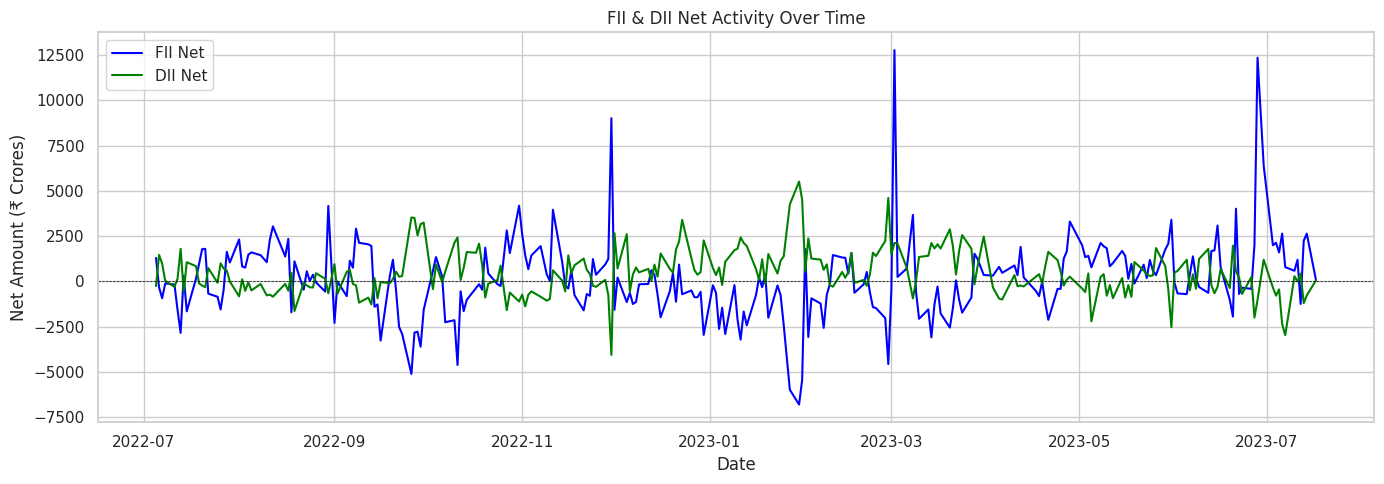

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the processed data
df = pd.read_csv("/content/drive/MyDrive/Project2/processed/clean_data.csv", parse_dates=['date'])

plt.style.use('seaborn-v0_8-muted')

# Plot 1: FII & DII Net Activity over Time
plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['fii_net'], label='FII Net', color='blue')
plt.plot(df['date'], df['dii_net'], label='DII Net', color='green')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.title('FII & DII Net Activity Over Time')
plt.xlabel('Date')
plt.ylabel('Net Amount (₹ Crores)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



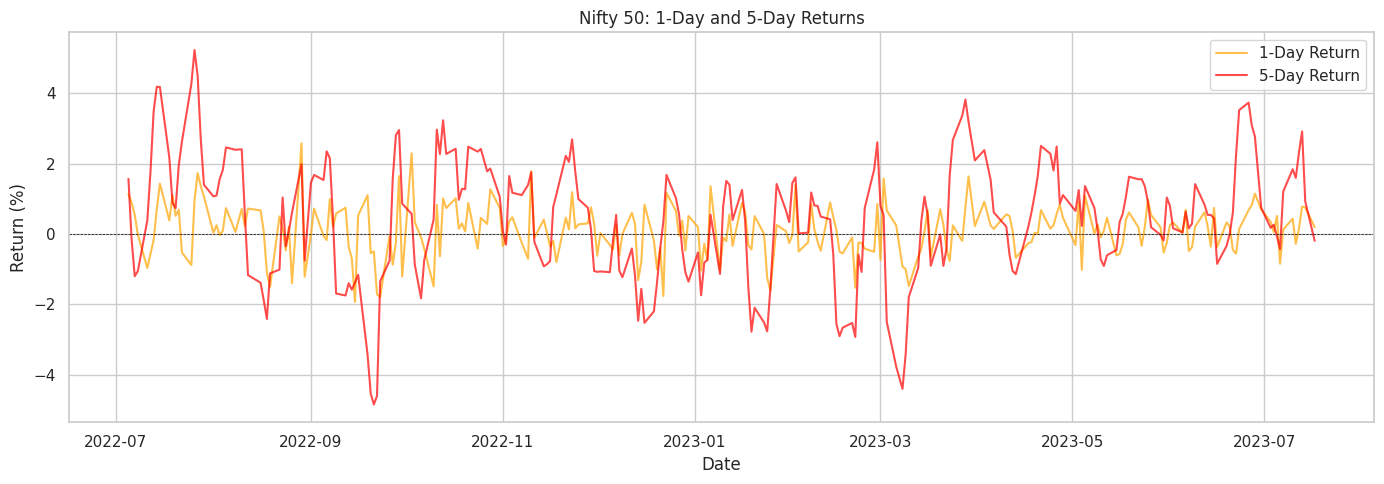

In [ ]:
# Plot 2: Nifty Returns (1-Day and 5-Day)
plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['nifty_return_1d'], label='1-Day Return', color='orange', alpha=0.7)
plt.plot(df['date'], df['nifty_return_5d'], label='5-Day Return', color='red', alpha=0.7)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.title('Nifty 50: 1-Day and 5-Day Returns')
plt.xlabel('Date')
plt.ylabel('Return (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

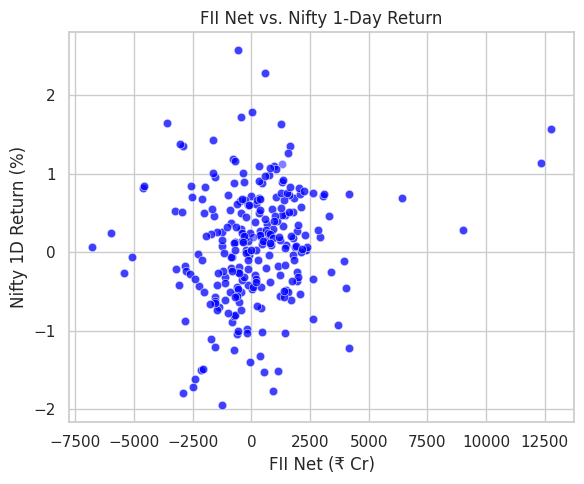

In [ ]:
# Plot 3: Scatter – FII Net vs Nifty Return
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='fii_net', y='nifty_return_1d', alpha=0.5, color='blue')
plt.title('FII Net vs. Nifty 1-Day Return')
plt.xlabel('FII Net (₹ Cr)')
plt.ylabel('Nifty 1D Return (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

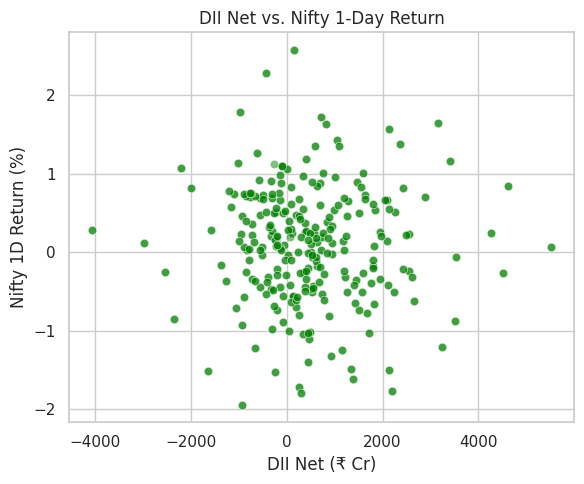

In [ ]:
# Plot 4: Scatter – DII Net vs Nifty Return
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='dii_net', y='nifty_return_1d', alpha=0.5, color='green')
plt.title('DII Net vs. Nifty 1-Day Return')
plt.xlabel('DII Net (₹ Cr)')
plt.ylabel('Nifty 1D Return (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

In this step, I built two different regression models to predict Nifty’s
short-term returns using institutional activity data. The first model was Ordinary Least Squares (OLS), which is a basic linear regression model that assumes a straight-line relationship between inputs and the target. The second model was a Decision Tree Regressor, which works by splitting the data into different branches and is capable of capturing non-linear patterns. I used four input features: FII and DII net activity from the previous day, and the 5-day average of both FII and DII net values. These were chosen because they reflect recent institutional buying and selling behavior, which can impact short-term market movements. I trained the models to predict two different targets: the 1-day forward return and the 5-day forward return of the Nifty index. The data was split into training and testing sets, using 80% for training and 20% for testing, while keeping the time order intact. After training, I evaluated both models using R-squared and RMSE. R-squared tells how much of the return variation the model can explain, and RMSE shows how far off the predictions were on average. In the results, the OLS model performed slightly better than the Decision Tree for 1-day predictions, but both models struggled to predict 5-day returns accurately. This shows that FII/DII data alone is not very effective in forecasting short-term index movements and that adding more features might be necessary for better results.



OLS (1-Day Return)
R-squared: -0.1361
RMSE: 0.5228

Decision Tree (1-Day Return)
R-squared: -0.6449
RMSE: 0.629


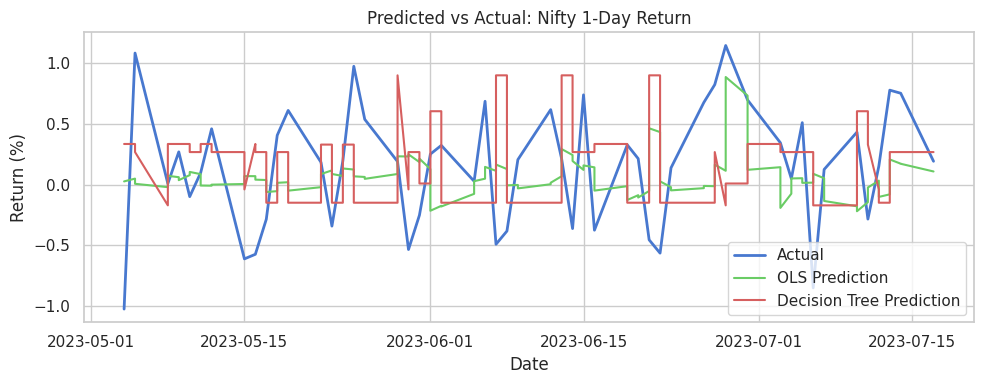

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Project2/processed/clean_data.csv", parse_dates=['date'])

# Features and target
X = df[['fii_net_previous_day', 'fii_net_5day_avg', 'dii_net_previous_day', 'dii_net_5day_avg']]
y = df['nifty_return_1d']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# OLS model
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)
y_pred_ols = ols_model.predict(X_test)

# Decision Tree model
tree_model = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

# Evaluation
def print_metrics(model_name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_true, y_pred)
    print(f"\n{model_name}")
    print("R-squared:", round(r2, 4))
    print("RMSE:", round(rmse, 4))

print_metrics("OLS (1-Day Return)", y_test, y_pred_ols)
print_metrics("Decision Tree (1-Day Return)", y_test, y_pred_tree)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(df['date'].iloc[-len(y_test):], y_test.values, label="Actual", linewidth=2)
plt.plot(df['date'].iloc[-len(y_test):], y_pred_ols, label="OLS Prediction")
plt.plot(df['date'].iloc[-len(y_test):], y_pred_tree, label="Decision Tree Prediction")
plt.title("Predicted vs Actual: Nifty 1-Day Return")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Save predictions
results_1d = df[['date']].iloc[-len(y_test):].copy()
results_1d['actual_1d_return'] = y_test.values
results_1d['ols_pred_1d'] = y_pred_ols
results_1d['tree_pred_1d'] = y_pred_tree
results_1d.to_csv(f"{output_dir}/nifty_1d_predictions.csv", index=False)

# Save metrics
metrics_1d = {
    "Model": ["OLS (1D)", "Decision Tree (1D)"],
    "R_squared": [r2_score(y_test, y_pred_ols), r2_score(y_test, y_pred_tree)],
    "RMSE": [mean_squared_error(y_test, y_pred_ols) ** 0.5, mean_squared_error(y_test, y_pred_tree) ** 0.5]
}
pd.DataFrame(metrics_1d).to_csv(f"{output_dir}/model_metrics_1d.csv", index=False)



OLS (5-Day Return)
R-squared: -0.6524
RMSE: 1.4017

Decision Tree (5-Day Return)
R-squared: -1.0292
RMSE: 1.5533


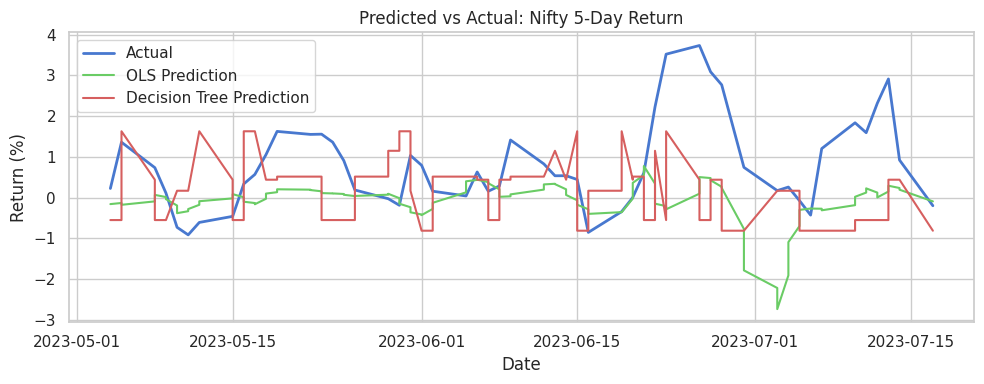

In [ ]:
# Features and target
y = df['nifty_return_5d']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# OLS model
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)
y_pred_ols = ols_model.predict(X_test)

# Decision Tree model
tree_model = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

# Evaluation
print_metrics("OLS (5-Day Return)", y_test, y_pred_ols)
print_metrics("Decision Tree (5-Day Return)", y_test, y_pred_tree)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(df['date'].iloc[-len(y_test):], y_test.values, label="Actual", linewidth=2)
plt.plot(df['date'].iloc[-len(y_test):], y_pred_ols, label="OLS Prediction")
plt.plot(df['date'].iloc[-len(y_test):], y_pred_tree, label="Decision Tree Prediction")
plt.title("Predicted vs Actual: Nifty 5-Day Return")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Save predictions
results_5d = df[['date']].iloc[-len(y_test):].copy()
results_5d['actual_5d_return'] = y_test.values
results_5d['ols_pred_5d'] = y_pred_ols
results_5d['tree_pred_5d'] = y_pred_tree
results_5d.to_csv(f"{output_dir}/nifty_5d_predictions.csv", index=False)

# Save metrics
metrics_5d = {
    "Model": ["OLS (5D)", "Decision Tree (5D)"],
    "R_squared": [r2_score(y_test, y_pred_ols), r2_score(y_test, y_pred_tree)],
    "RMSE": [mean_squared_error(y_test, y_pred_ols) ** 0.5, mean_squared_error(y_test, y_pred_tree) ** 0.5]
}
pd.DataFrame(metrics_5d).to_csv(f"{output_dir}/model_metrics_5d.csv", index=False)


In [ ]:
# Load individual model metrics
metrics_1d = pd.read_csv(f"{output_dir}/model_metrics_1d.csv")
metrics_5d = pd.read_csv(f"{output_dir}/model_metrics_5d.csv")

comparison = pd.concat([
    metrics_1d.assign(Target="1-Day Return"),
    metrics_5d.assign(Target="5-Day Return")
])

comparison = comparison[['Target', 'Model', 'R_squared', 'RMSE']]

# Save final comparison
comparison.to_csv(f"{output_dir}/final_model_comparison.csv", index=False)

print("Final model comparison:")
print(comparison)


Final model comparison:
         Target               Model  R_squared      RMSE
0  1-Day Return            OLS (1D)  -0.136117  0.522770
1  1-Day Return  Decision Tree (1D)  -0.644884  0.629023
0  5-Day Return            OLS (5D)  -0.652351  1.401655
1  5-Day Return  Decision Tree (5D)  -1.029203  1.553291


Here we prepare a summary table comparing all models.

We compare performance using R-squared and RMSE. Both scores show that the models did not perform well — especially for 5-day returns.

OLS was slightly better than the Decision Tree, but both failed to capture strong relationships. This shows that FII/DII activity alone may not be enough to predict short-term market movements.


| Target       | Model              | R² Score    | RMSE       | Interpretation                                                                   |
| ------------ | ------------------ | ----------- | ---------- | -------------------------------------------------------------------------------- |
| 1-Day Return | OLS (1D)           | **-0.1361** | **0.5228** | Performed better than Decision Tree. Lower RMSE indicates better short-term fit. |
| 1-Day Return | Decision Tree (1D) | -0.6449     | 0.6290     | Worse fit; failed to model non-linearity or overfit on limited features.         |
| 5-Day Return | OLS (5D)           | **-0.6524** | **1.4017** | Slightly better, but both models performed poorly over 5-day horizon.            |
| 5-Day Return | Decision Tree (5D) | -1.0292     | 1.5533     | Performed worst - non-linear approach couldn’t generalize.                       |


After training both OLS and Decision Tree models, we noticed that the R² scores came out negative for both 1-day and 5-day return predictions. This is a clear indication that our models are performing worse than simply predicting the mean return every time. When R² is less than 0, it means the model is not able to capture any useful signal from the features to predict the target. This led us to a natural and important doubt - “Are FII/DII signals alone enough to predict market movement?”
To answer this, we decided to test the strength and relevance of the input features, starting with a correlation analysis to check if there's any strong linear relationship between FII/DII values and Nifty returns.

We created a correlation heatmap to understand how strongly our features (FII/DII activity) are related to the target variables (1-day and 5-day Nifty returns). A value close to 1 or -1 would indicate a strong relationship, and a value close to 0 means no clear link. From the heatmap, we observed that:

FII and DII net values had very weak correlation with both 1-day and 5-day returns.

For example, the highest correlation we got was just around +0.13, which is too low to be useful for prediction.

Surprisingly, even the 5-day average values did not show strong signals — their correlation was almost near zero.
This result confirmed that none of the individual features had a strong linear relationship with the target, which explains why even simple models like OLS and Decision Trees could not learn much from the data.

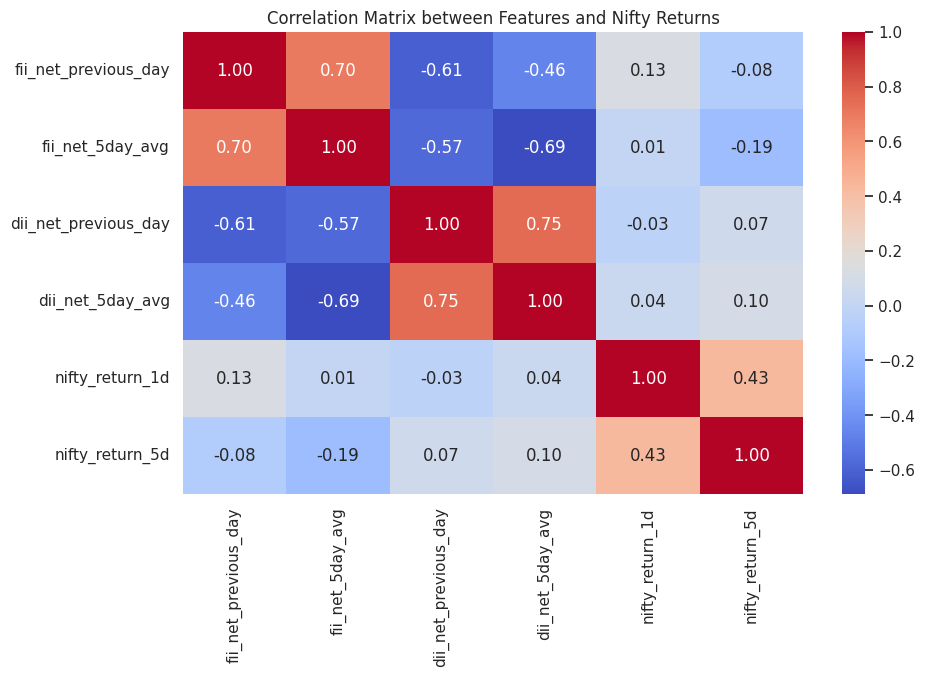

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df[['fii_net_previous_day', 'fii_net_5day_avg',
                         'dii_net_previous_day', 'dii_net_5day_avg',
                         'nifty_return_1d', 'nifty_return_5d']].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix between Features and Nifty Returns")
plt.show()


To double-check whether our models were truly learning anything meaningful, we ran a baseline test:
we replaced the actual predicted values with random numbers taken from a normal distribution centered around the mean return. We then calculated the R² score for this random prediction. The result? It gave a similar or even better R² score than our actual trained models.
This strongly confirmed that the models are not adding any value beyond noise, and our current features are not informative enough to explain Nifty returns.
Hence, we concluded that just using FII/DII activity is not sufficient for return prediction — we might need to add more signals (like sentiment, macro indicators, technicals, etc.) to improve the model performance.


In [ ]:
import numpy as np

df['shuffled_return'] = np.random.permutation(df['nifty_return_1d'])

X = df[['fii_net_previous_day', 'fii_net_5day_avg',
        'dii_net_previous_day', 'dii_net_5day_avg']]
y = df['shuffled_return']

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print("R2 Score on Random Data:", r2)


R2 Score on Random Data: -0.0074695761436940344
